## House Price Prediction in Delhi)))

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import category_encoders as ce

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import seaborn as sns

In [19]:
df = pd.read_csv('Delhi.csv')
df

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,10500000,1200,Sector 10 Dwarka,2,1,0,1,0,0,1,...,1,0,1,0,0,0,0,0,0,0
1,6000000,1000,Uttam Nagar,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15000000,1350,Sarita Vihar,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2500000,435,Uttam Nagar,2,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,5800000,900,Dwarka Mor,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,2500000,540,Madhu Vihar,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4994,3000000,540,Madhu Vihar,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4995,2600000,415,Sector 26 Dwarka,1,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4996,5500000,415,Sector 26 Dwarka,1,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [20]:
df.shape

(4998, 40)

##преобразуем категориальную переменну 'Location' в численную

In [21]:
df['Location'].unique().shape


(339,)

так как уникальных значений у переменной 'Location' много, то нужно что-то придумывать. Я почитал про виды encoding'а и пришел к выводу, что можно использовать target encoding вместо label encoding (значению сопоставляется уникальное число): он заменяет катег переменные на средние значения целевой переменной,то есть цены аппартаментов

In [22]:
df

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,10500000,1200,Sector 10 Dwarka,2,1,0,1,0,0,1,...,1,0,1,0,0,0,0,0,0,0
1,6000000,1000,Uttam Nagar,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15000000,1350,Sarita Vihar,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2500000,435,Uttam Nagar,2,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,5800000,900,Dwarka Mor,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,2500000,540,Madhu Vihar,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4994,3000000,540,Madhu Vihar,2,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4995,2600000,415,Sector 26 Dwarka,1,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
4996,5500000,415,Sector 26 Dwarka,1,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [23]:
# Создаем экземпляр Target Encoder
target_encoder = ce.TargetEncoder(cols=['Location'])

# Применяем Target Encoding к категориальной переменной
encoded_data = target_encoder.fit_transform(df['Location'], df['Price'])

# Объединяем закодированные данные с исходными данными
data = df.join(encoded_data.add_suffix('_target'))

# Выводим результат
print(data)

         Price  Area          Location  No. of Bedrooms  Resale  \
0     10500000  1200  Sector 10 Dwarka                2       1   
1      6000000  1000       Uttam Nagar                3       0   
2     15000000  1350      Sarita Vihar                2       1   
3      2500000   435       Uttam Nagar                2       0   
4      5800000   900        Dwarka Mor                3       0   
...        ...   ...               ...              ...     ...   
4993   2500000   540       Madhu Vihar                2       1   
4994   3000000   540       Madhu Vihar                2       1   
4995   2600000   415  Sector 26 Dwarka                1       1   
4996   5500000   415  Sector 26 Dwarka                1       1   
4997   4200000   900       Uttam Nagar                3       1   

      MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  \
0                    0          1             0                  0   
1                    0          0             0        

In [24]:
data = data.drop('Location', axis = 1)
data

,Price,Area,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,RainWaterHarvesting,...,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium,Location_target
0,10500000,1200,2,1,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1.556579e+07
1,6000000,1000,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.609370e+06
2,15000000,1350,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.391685e+07
3,2500000,435,2,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,5.609370e+06
4,5800000,900,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.223202e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,2500000,540,2,1,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,1.417106e+07
4994,3000000,540,2,1,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,1.417106e+07
4995,2600000,415,1,1,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,1.565164e+07
4996,5500000,415,1,1,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,1.565164e+07


##пытаемся в PCA

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
from sklearn import datasets
from mpl_toolkits.mplot3d import Axes3D

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


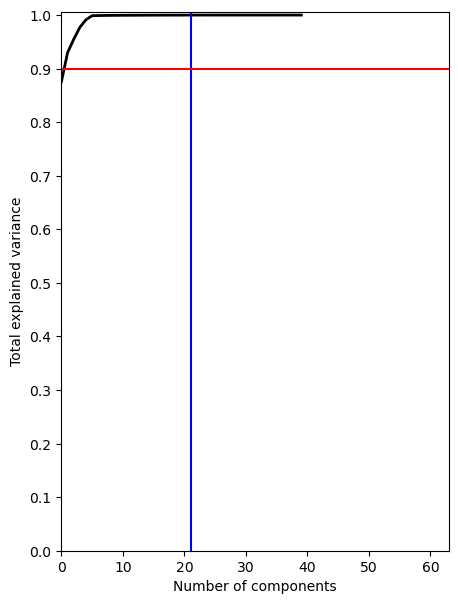

In [26]:
pca = decomposition.PCA().fit(data_scaled)

plt.figure(figsize=(5,7))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='k', lw=2)
plt.xlabel('Number of components')
plt.ylabel('Total explained variance')
plt.xlim(0, 63)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.axvline(21, c='b')
plt.axhline(0.9, c='r')
plt.show();

теперь перейдем к созданию псевдообратной матрицы

In [184]:
data = data.assign(Ones=1) #добавляем еще 1 столбец, отвечающий за свободный член в уравнение b1 = k1x1 + k2x2 + .. + (y1
data.shape

(4998, 41)

## Поиск вектора Х линейной регрессии

решаем систему уравнений  𝐴𝑋=B и находим ее псевдорешение

In [185]:
x2 = data.drop('Price',axis=1)
y2 = data['Price']
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.4, random_state=100)
x2_train = np.matrix(x2_train)

#x2_train - матрица А
#y2_train - столбец свободных членов
a = np.matrix(x2_train)
b = np.matrix(y2_train).T
print(a.shape)
print(b.shape)
x2_train


(2998, 40)
(2998, 1)


matrix([[9.00000000e+02, 3.00000000e+00, 1.00000000e+00, ...,
         0.00000000e+00, 1.48072801e+07, 1.00000000e+00],
        [1.17000000e+03, 3.00000000e+00, 1.00000000e+00, ...,
         0.00000000e+00, 3.53824530e+06, 1.00000000e+00],
        [1.38100000e+03, 3.00000000e+00, 0.00000000e+00, ...,
         9.00000000e+00, 1.82092375e+07, 1.00000000e+00],
        ...,
        [7.50000000e+02, 2.00000000e+00, 1.00000000e+00, ...,
         0.00000000e+00, 3.53824530e+06, 1.00000000e+00],
        [5.40000000e+02, 2.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 3.53824530e+06, 1.00000000e+00],
        [8.00000000e+02, 2.00000000e+00, 1.00000000e+00, ...,
         9.00000000e+00, 2.67708672e+06, 1.00000000e+00]])

In [186]:
a_po = np.linalg.pinv(a) #псевдообратная матрица
print(a_po.shape)
x_po = np.dot(a_po, b) #наши коэффициенты линейной регрессии 
print(x_po)
print(x_po.shape) #проверка

(40, 2998)
[[ 2.02626643e+04]
 [-6.11648886e+06]
 [-9.60866524e+06]
 [ 1.08987598e+06]
 [-1.54660243e+06]
 [ 1.96698464e+06]
 [-5.23048993e+04]
 [-1.23364301e+06]
 [-3.28666944e+06]
 [ 3.37034404e+06]
 [ 3.51736863e+06]
 [-2.83107488e+06]
 [-9.95350292e+04]
 [ 2.25841491e+06]
 [-1.29785594e+06]
 [ 1.14709360e+07]
 [ 2.49242530e+06]
 [-2.82221614e+06]
 [-1.38473488e+06]
 [-1.81985037e+06]
 [-1.58467904e+06]
 [-1.13930476e+06]
 [-1.45561918e+07]
 [-1.06253124e+06]
 [-3.34368174e+06]
 [-1.88539700e+06]
 [ 1.30059487e+06]
 [-1.26328652e+06]
 [ 3.78646712e+06]
 [-4.68538408e+06]
 [ 3.50746964e+06]
 [-4.64602132e+06]
 [ 1.30059487e+06]
 [ 2.62031846e+06]
 [ 4.68964231e+06]
 [-8.99484445e+05]
 [ 1.30059487e+06]
 [ 7.25197607e+06]
 [ 8.52391070e-01]
 [ 1.27907715e+05]]
(40, 1)


## Проверяем модель

In [187]:
pred2 =x2_test @ x_po

pred2 = np.array(pred2).flatten()
print(pred2.shape)
print(y2_test.shape) #привожу столбцы к одному типу

print('MAE = ', mean_absolute_error(y2_test,pred2))
print('MSE = ', mean_squared_error(y2_test,pred2))
compare2 = pd.DataFrame({'Actual':y2_test,'Predicted':pred2})
print(compare2.shape)

(2000,)
(2000,)
MAE =  14235653.23373299
MSE =  1951576115678158.0
(2000, 2)


## Визуализируем полученный результат

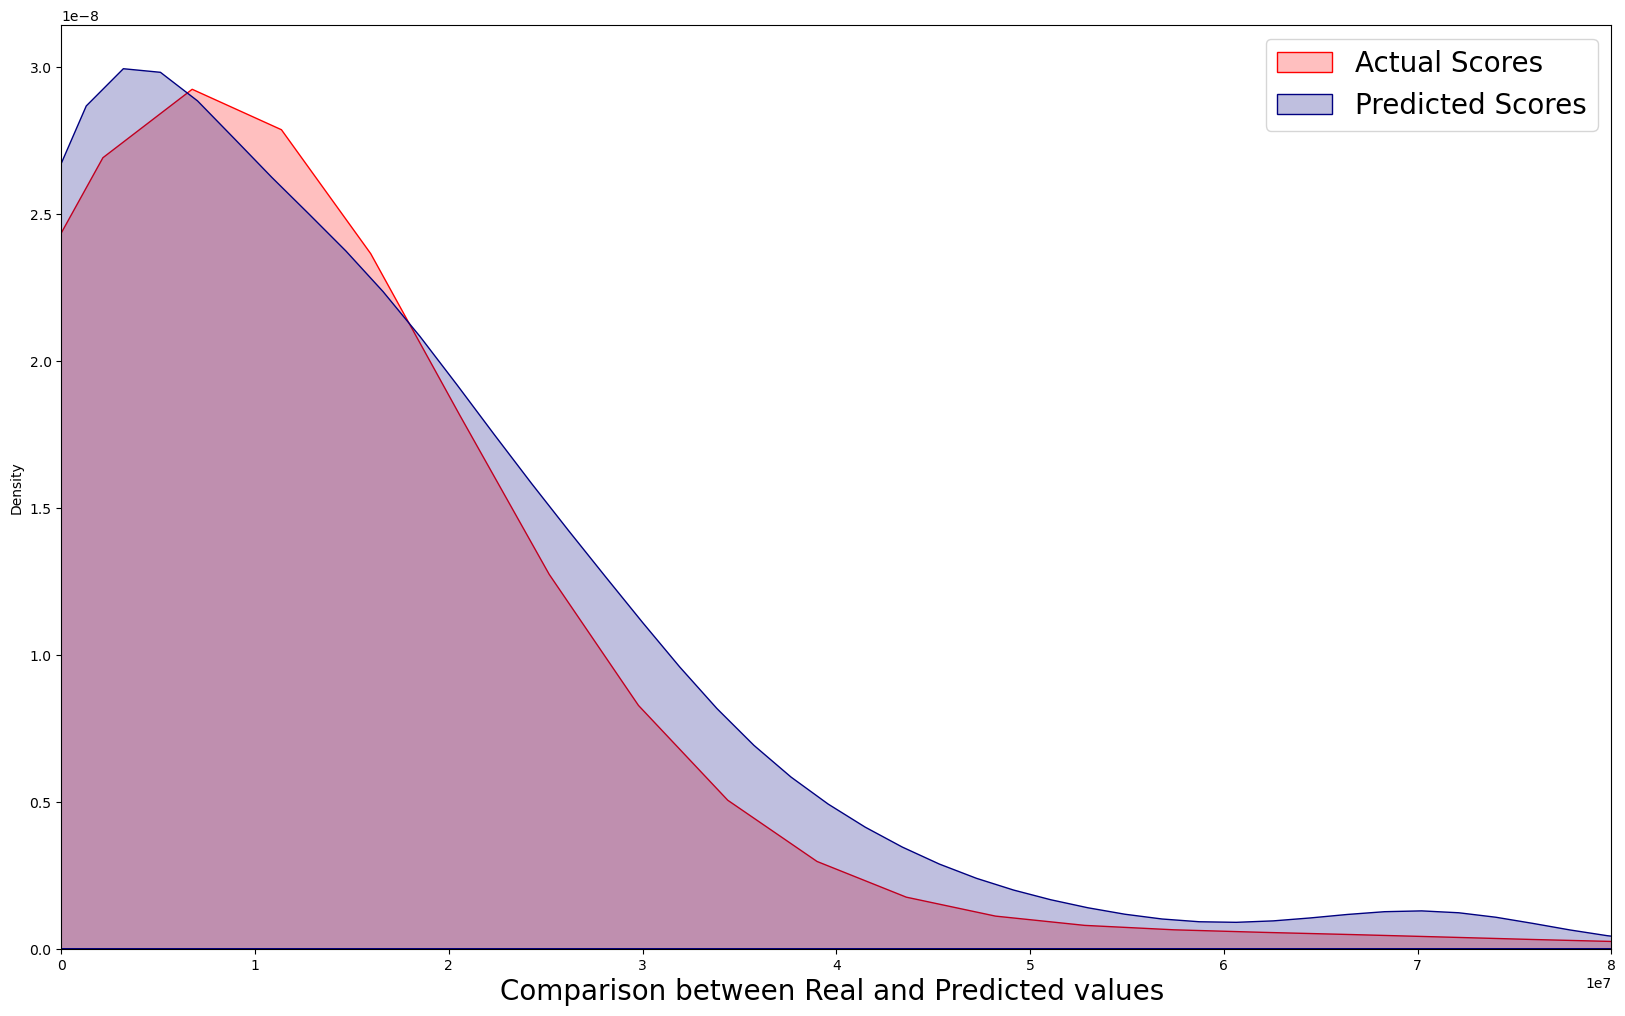

In [188]:
plt.figure(figsize=(20,12))
plt.xlim(0,80000000)
plt.xlabel('Comparison between Real and Predicted values ', fontsize=20)
a=sns.kdeplot(compare2['Actual'],shade=True,color='red')
b=sns.kdeplot(compare2['Predicted'],color='navy',shade=True)
plt.legend(labels=['Actual Scores','Predicted Scores'],fontsize=20)
plt.show()